Mounted at /content/drive
DEVICE: cpu
MODEL LOADED.
Images found: 19
TASK 5 COMPLETED — Predictions saved!


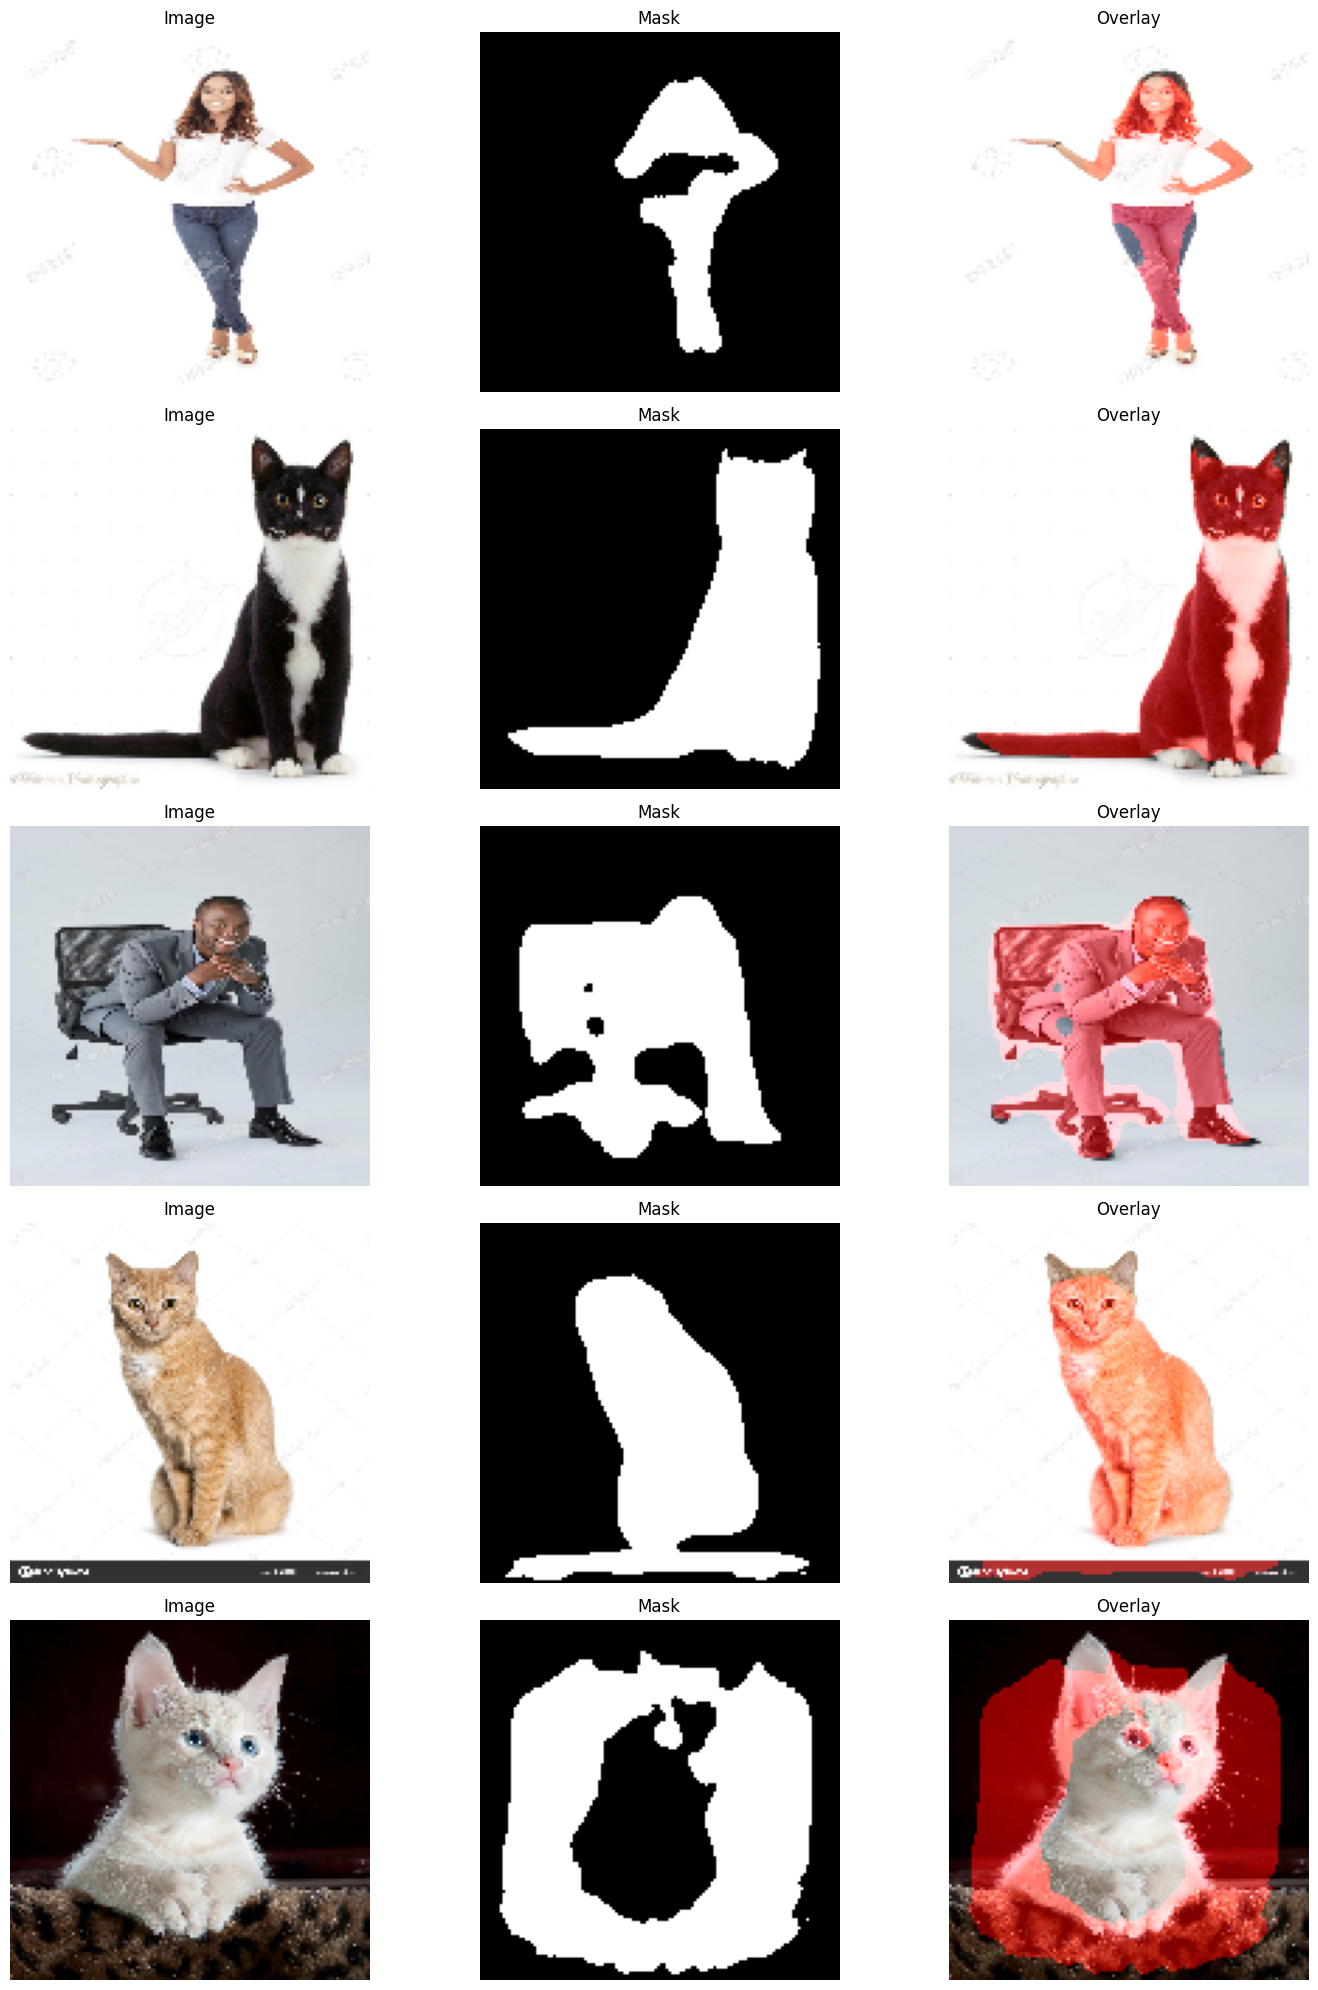

In [1]:
# ===============================
# TASK 5 — PREDICT ON INTERNET IMAGES
# (New Colab Notebook)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

import torch, torch.nn as nn
import cv2, os, numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# --------- PATHS ----------
MODEL_PATH = "/content/drive/MyDrive/unet_task4_fast_final.pth"
IMG_DIR    = "/content/drive/MyDrive/internet images"
SAVE_DIR   = "/content/drive/MyDrive/coco20k/task5_predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 128   # must match task-4


# ========= UNET LITE (same as Task-4) =========
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.ReLU()
        )
    def forward(self, x): return self.c(x)

class UNetLite(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3,32)
        self.d2 = DoubleConv(32,64)
        self.d3 = DoubleConv(64,128)
        self.bott = DoubleConv(128,256)

        self.up3 = nn.ConvTranspose2d(256,128,2,2)
        self.u3  = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.u2  = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.u1  = DoubleConv(64,32)

        self.out = nn.Conv2d(32,1,1)

    def forward(self,x):
        c1 = self.d1(x); p1 = nn.MaxPool2d(2)(c1)
        c2 = self.d2(p1); p2 = nn.MaxPool2d(2)(c2)
        c3 = self.d3(p2); p3 = nn.MaxPool2d(2)(c3)
        c4 = self.bott(p3)

        u3 = self.up3(c4); u3 = self.u3(torch.cat([u3,c3],1))
        u2 = self.up2(u3); u2 = self.u2(torch.cat([u2,c2],1))
        u1 = self.up1(u2); u1 = self.u1(torch.cat([u1,c1],1))

        return self.out(u1)


# ========= LOAD MODEL =========
model = UNetLite().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("MODEL LOADED.")


# ========= GET 20 INTERNET IMAGES =========
paths = sorted([os.path.join(IMG_DIR,f)
                for f in os.listdir(IMG_DIR)
                if f.lower().endswith((".jpg",".png",".jpeg"))])[:20]

print("Images found:", len(paths))


# ========= RUN PREDICTION =========
for i, p in enumerate(paths):
    img = cv2.imread(p)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    arr = resized.astype(np.float32)/255.0
    arr = np.transpose(arr, (2,0,1))
    t = torch.tensor(arr).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(t))[0,0].cpu().numpy()

    pred_bin = (pred > 0.5).astype("uint8")

    # overlay
    mask_color = np.zeros_like(resized)
    mask_color[:,:,0] = pred_bin * 255
    overlay = cv2.addWeighted(resized, 1, mask_color, 0.5, 0)

    # save images
    cv2.imwrite(f"{SAVE_DIR}/img_{i}.png", cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f"{SAVE_DIR}/mask_{i}.png", pred_bin*255)
    cv2.imwrite(f"{SAVE_DIR}/overlay_{i}.png", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("TASK 5 COMPLETED — Predictions saved!")



# ========= DISPLAY 5 SAMPLES =========
plt.figure(figsize=(15,20))
k = 1

for i in range(5):
    img = cv2.imread(f"{SAVE_DIR}/img_{i}.png")
    mask = cv2.imread(f"{SAVE_DIR}/mask_{i}.png",0)
    overlay = cv2.imread(f"{SAVE_DIR}/overlay_{i}.png")

    plt.subplot(5,3,k); k+=1
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Image"); plt.axis("off")

    plt.subplot(5,3,k); k+=1
    plt.imshow(mask, cmap="gray")
    plt.title("Mask"); plt.axis("off")

    plt.subplot(5,3,k); k+=1
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay"); plt.axis("off")

plt.tight_layout()
plt.show()
